In [3]:
import numpy as np
from pyrokinetics import Pyro, PyroHypercube
from pathlib import Path
import xarray as xr
import matplotlib.pyplot as plt

In [4]:
project = "MFAMILY_NEW"
KBM_cases = ["KB_MODELS_MAST","KB_MODELS_R4"]
GYRO_DATA = Path("/mnt/data/Gyrokinetic_Simulations")
#GFTM_VERSIONS = ["m3_new", "m5_new" , "m7_new" , "m9_new" , "m11_new"]
GFTM_VERSIONS = ["m11_new"]

In [5]:
gs2_KBM_cases = ["M1","R4"]
gs2_cube_dict_kbm = {}
for case in gs2_KBM_cases:
    gs2_cube_json = GYRO_DATA / "GS2" / "Runs"/ "LATIN_HYPERCUBE" / case / "kbm_8d" / "pyro_cube" /   "pyroscan.json"
    gs2_cube_net_cdf = GYRO_DATA / "GS2" / "Runs" / "LATIN_HYPERCUBE" / case / "kbm_8d" /"pyro_cube" /  "cube.nc"
    gs2_cube = PyroHypercube(pyroscan_json=gs2_cube_json, load_base_pyro=True)
    gs2_cube.load_gk_output(netcdf_file=gs2_cube_net_cdf)
    gs2_cube_dict_kbm[case] = gs2_cube

/home/Felix/Documents/Physics_Work/Project_Codes/gftm_analysis/pyrokinetics/src/pyrokinetics/pyro.py:1788: UserWarning: Explicitly set value of beta (0.0005579564509906401 beta_ref_ee_B0_pyroscan_base0000) is inconsistent with value from physical reference values (0.036316584746068435 beta_ref_ee_B0_pyroscan_base0000)
  warnings.warn(


/home/Felix/Documents/Physics_Work/Project_Codes/gftm_analysis/.venv/lib/python3.14/site-packages/xarray/core/variable.py:363: UnitStrippedWarning: The unit of the quantity is stripped when downcasting to ndarray.
  data = np.asarray(data)


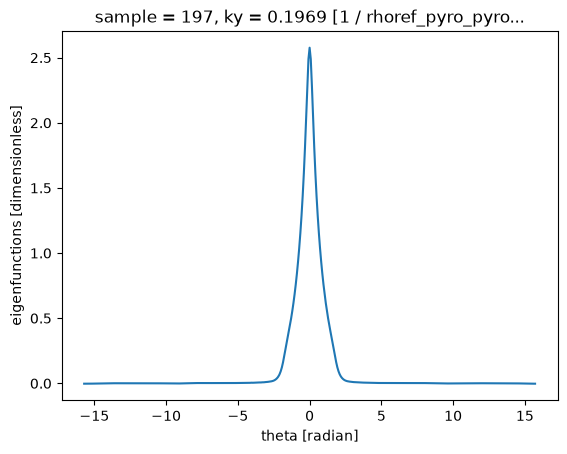

In [6]:
np.real(gs2_cube_dict_kbm["M1"].gk_output.data["eigenfunctions"].sel(field = "phi").sel(sample = 197)).plot()

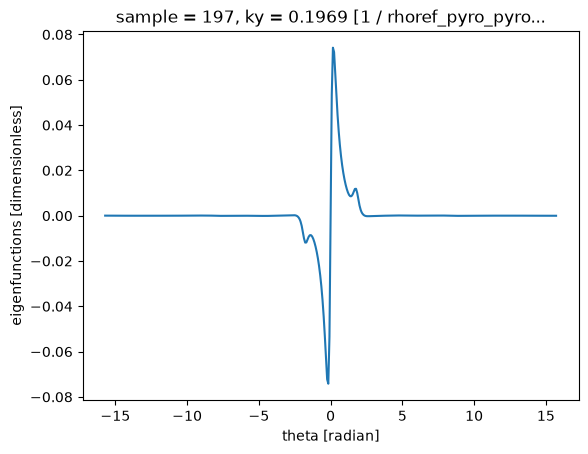

In [7]:
np.real(gs2_cube_dict_kbm["M1"].gk_output.data["eigenfunctions"].sel(field = "apar").sel(sample = 197)).plot()

In [8]:
pyro_cube_dict_kbm = {}

for case in KBM_cases:
    pyro_cube_sub_dict = {}

    for version in GFTM_VERSIONS:
        Pyro_cube_json = (
            GYRO_DATA / "GFTM" / "Runs" / project / case / version / "pyro_cube" / "pyroscan.json"
        )
        Pyro_cube_net_cdf = (
            GYRO_DATA / "GFTM" / "Runs" / project / case / version / "pyro_cube" / "cube.nc"
        )

        pyro_cube = PyroHypercube(
            pyroscan_json=Pyro_cube_json,
            load_base_pyro=True,
        )
        pyro_cube.load_gk_output(netcdf_file=Pyro_cube_net_cdf)

        pyro_cube_sub_dict[version] = pyro_cube

    pyro_cube_dict_kbm[case] = pyro_cube_sub_dict



/home/Felix/Documents/Physics_Work/Project_Codes/gftm_analysis/.venv/lib/python3.14/site-packages/xarray/core/variable.py:363: UnitStrippedWarning: The unit of the quantity is stripped when downcasting to ndarray.
  data = np.asarray(data)


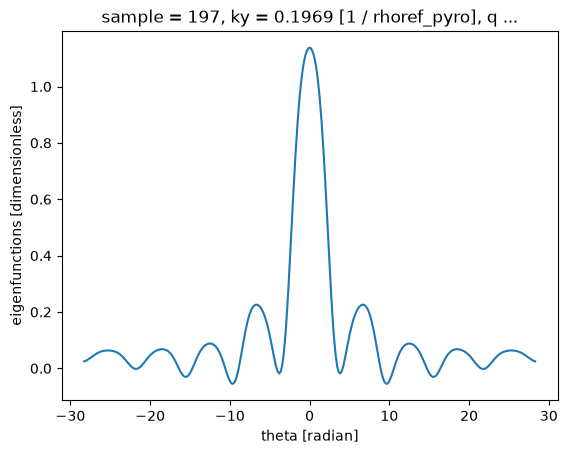

In [9]:
np.real(pyro_cube_dict_kbm["KB_MODELS_MAST"]["m11_new"].gk_output.data["eigenfunctions"].isel(mode=0).sel(sample = 197).sel(field = "phi")).plot()

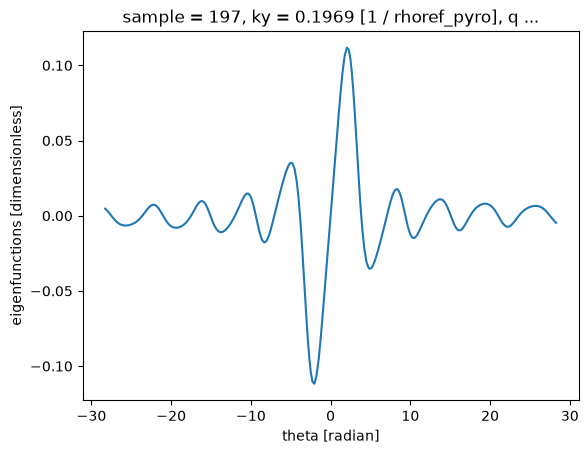

In [10]:
np.real(pyro_cube_dict_kbm["KB_MODELS_MAST"]["m11_new"].gk_output.data["eigenfunctions"].isel(mode=0).sel(sample = 197).sel(field = "apar")).plot()

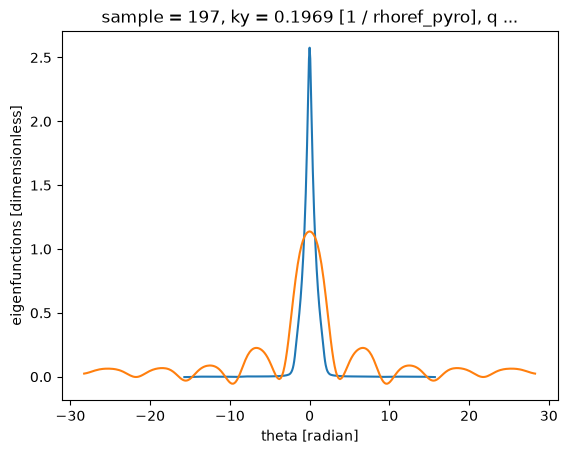

In [11]:
np.real(gs2_cube_dict_kbm["M1"].gk_output.data["eigenfunctions"].sel(field = "phi").sel(sample = 197)).plot()
np.real(pyro_cube_dict_kbm["KB_MODELS_MAST"]["m11_new"].gk_output.data["eigenfunctions"].isel(mode=0).sel(sample = 197).sel(field = "phi")).plot()

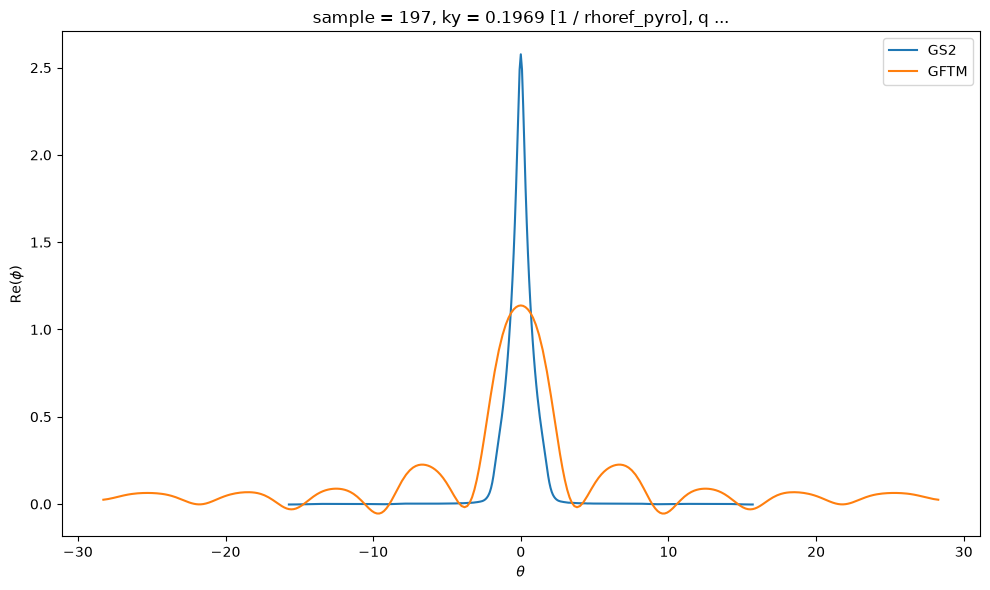

gs2_growth_rate=  0.10205824046271578. gftm_growth_rate = 0.75008
gs2 frequency =  -0.7193153441061862. gftm frequency = -0.98721


In [12]:
import matplotlib.pyplot as plt
import numpy as np
SAMPLE = 197
MODE = 0
# GS2
gs2_phi = (
    np.real(
        gs2_cube_dict_kbm["M1"]
        .gk_output.data["eigenfunctions"]
        .sel(field="phi")
        .sel(sample=SAMPLE)
    )
)

# GFTM
gftm_phi = (
    np.real(
        pyro_cube_dict_kbm["KB_MODELS_MAST"]["m11_new"]
        .gk_output.data["eigenfunctions"]
        .isel(mode=MODE)
        .sel(sample=SAMPLE)
        .sel(field="phi")
    )
)

fig, ax = plt.subplots(figsize=(10, 6))

gs2_phi.plot(ax=ax, label="GS2")
gftm_phi.plot(ax=ax, label="GFTM")

ax.set_xlabel(r"$\theta$")
ax.set_ylabel(r"$\mathrm{Re}(\phi)$")
ax.legend()

plt.tight_layout()
plt.show()

gs2_growth_rate = np.real(
        gs2_cube_dict_kbm["M1"]
        .gk_output.data["growth_rate"]
        .sel(sample=SAMPLE).values
    )
gs2_frequency = np.real(
        gs2_cube_dict_kbm["M1"]
        .gk_output.data["mode_frequency"]
        .sel(sample=SAMPLE).values
    )
gftm_growht_rate = np.real(
        pyro_cube_dict_kbm["KB_MODELS_MAST"]["m11_new"]
        .gk_output.data["growth_rate"]
        .isel(mode=MODE)
        .sel(sample=SAMPLE).values
    )
gftm_frequency = np.real(
        pyro_cube_dict_kbm["KB_MODELS_MAST"]["m11_new"]
        .gk_output.data["mode_frequency"]
        .isel(mode=MODE)
        .sel(sample=SAMPLE).values
    )
print(f"gs2_growth_rate=  {gs2_growth_rate}. gftm_growth_rate = {gftm_growht_rate}")
print(f"gs2 frequency =  {gs2_frequency}. gftm frequency = {gftm_frequency}")

In [13]:
gs2_cube_dict_kbm["M1"].gk_output.data["growth_rate"].sel(sample=SAMPLE)

<xarray.DataArray 'growth_rate' ()> Size: 8B
<Quantity(0.10205824046271578, 'vref_nrl_pyroscan_base0000 / lref_minor_radius_pyroscan_base0000')>
Coordinates:
    sample                   int64 8B 197
    ky                       float64 8B [1/rhoref_pyro_pyroscan_base0000] 0.1969
    q                        float64 8B [] 2.484
    shat                     float64 8B [] 4.829
    beta                     float64 8B [beta_ref_ee_B0_pyroscan_base0000] 0....
    deuterium_temp_gradient  float64 8B [1/lref_minor_radius_pyroscan_base0000] ...
    electron_temp_gradient   float64 8B [1/lref_minor_radius_pyroscan_base0000] ...
    electron_dens_gradient   float64 8B [1/lref_minor_radius_pyroscan_base0000] ...
    electron_nu              float64 8B [vref_nrl_pyroscan_base0000/lref_minor_radius_pyroscan_base0000] ...
    sample_name              <U13 52B 'iteration_197'

In [14]:
gs2_cube_dict_kbm["M1"].gk_output.data["ky"].sel(sample=SAMPLE)

<xarray.DataArray 'ky' ()> Size: 8B
<Quantity(0.19693522022022164, '1 / rhoref_pyro_pyroscan_base0000')>
Coordinates:
    sample                   int64 8B 197
    ky                       float64 8B [1/rhoref_pyro_pyroscan_base0000] 0.1969
    q                        float64 8B [] 2.484
    shat                     float64 8B [] 4.829
    beta                     float64 8B [beta_ref_ee_B0_pyroscan_base0000] 0....
    deuterium_temp_gradient  float64 8B [1/lref_minor_radius_pyroscan_base0000] ...
    electron_temp_gradient   float64 8B [1/lref_minor_radius_pyroscan_base0000] ...
    electron_dens_gradient   float64 8B [1/lref_minor_radius_pyroscan_base0000] ...
    electron_nu              float64 8B [vref_nrl_pyroscan_base0000/lref_minor_radius_pyroscan_base0000] ...
    sample_name              <U13 52B 'iteration_197'

In [15]:
pyro_cube_dict_kbm["KB_MODELS_MAST"]["m11_new"].gk_output.data["ky"].sel(sample=SAMPLE)

<xarray.DataArray 'ky' ()> Size: 8B
<Quantity(0.19693522022022167, '1 / rhoref_pyro')>
Coordinates:
    sample                   int64 8B 197
    ky                       float64 8B [1/rhoref_pyro] 0.1969
    q                        float64 8B [] 2.484
    shat                     float64 8B [] 4.829
    beta                     float64 8B [beta_ref_ee_B0] 0.1239
    deuterium_temp_gradient  float64 8B [1/lref_minor_radius] 3.721
    electron_temp_gradient   float64 8B [1/lref_minor_radius] 3.243
    electron_dens_gradient   float64 8B [1/lref_minor_radius] 3.284
    electron_nu              float64 8B [vref_nrl/lref_minor_radius] 0.06287
    sample_name              <U13 52B 'iteration_197'

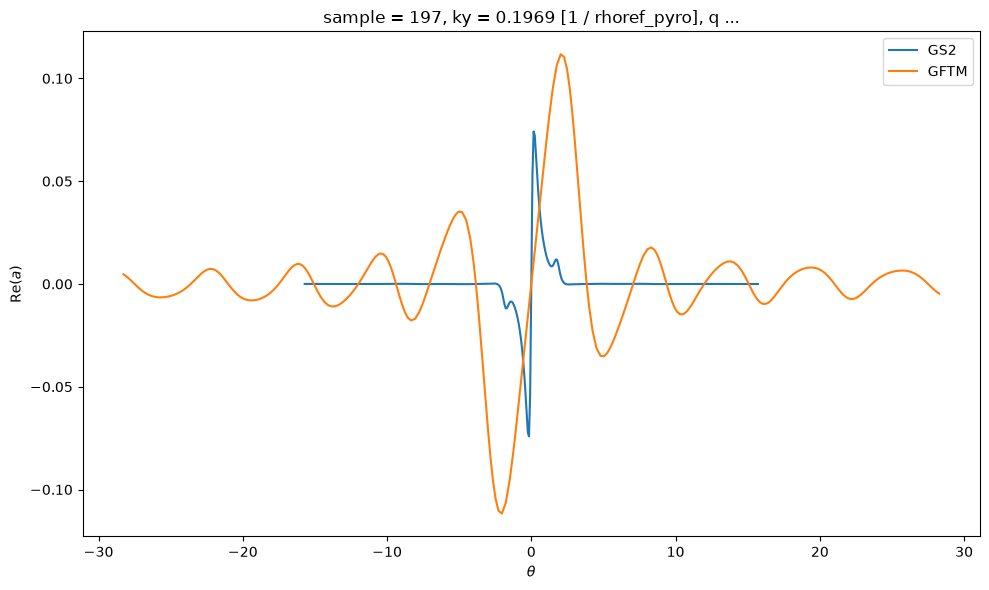

In [16]:
import matplotlib.pyplot as plt
import numpy as np
SAMPLE = 197
MODE = 0
# GS2
gs2_phi = (
    np.real(
        gs2_cube_dict_kbm["M1"]
        .gk_output.data["eigenfunctions"]
        .sel(field="apar")
        .sel(sample=SAMPLE)
    )
)

# GFTM
gftm_phi = (
    np.real(
        pyro_cube_dict_kbm["KB_MODELS_MAST"]["m11_new"]
        .gk_output.data["eigenfunctions"]
        .isel(mode=0)
        .sel(sample=SAMPLE)
        .sel(field="apar")
    )
)

fig, ax = plt.subplots(figsize=(10, 6))

gs2_phi.plot(ax=ax, label="GS2")
gftm_phi.plot(ax=ax, label="GFTM")

ax.set_xlabel(r"$\theta$")
ax.set_ylabel(r"$\mathrm{Re}(a)$")
ax.legend()

plt.tight_layout()
plt.show()

In [17]:
# specific cgyro simulation
cgyro_location = "/mnt/data/Gyrokinetic_Simulations/CGYRO/Runs/kbm_m1_iter197_cgyro/M1/iteration_197/input.cgyro"
pyro_cgyro = Pyro(gk_file = cgyro_location)

In [18]:
pyro_cgyro.load_gk_output()

In [23]:
pyro_cgyro.gk_output["growth_rate"].isel(time= -1)

Magnitude,[[0.09343914929907156]]
Units,vref_nrl/lref_minor_radius


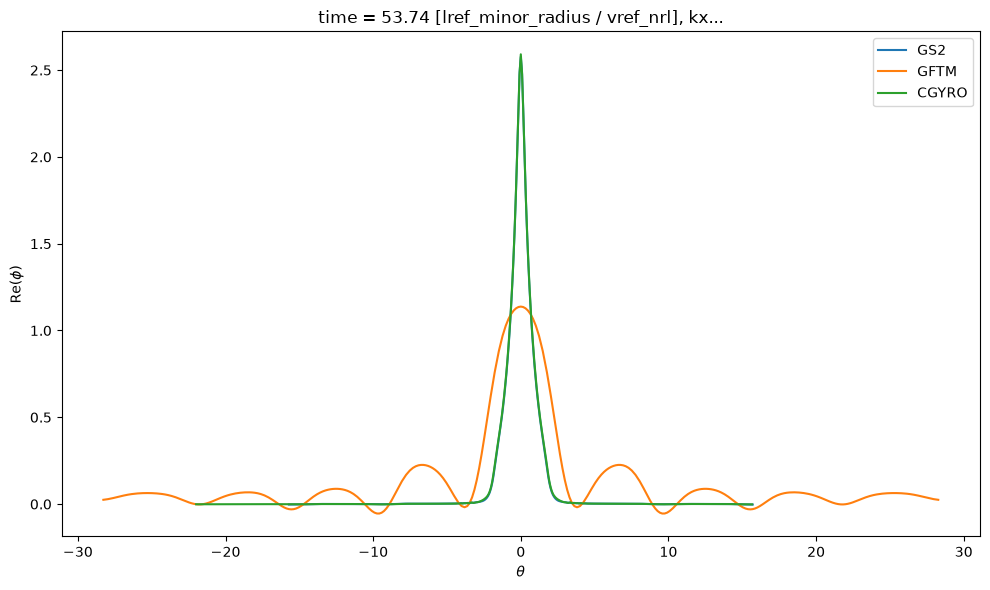

gs2_growth_rate=  0.10205824046271578. gftm_growth_rate = 0.75008. cgyro_growth_rate = [[0.09343915]]
gs2 frequency =  -0.7193153441061862. gftm frequency = -0.98721. cgyro_frequency = [[1.67494657]]


In [ ]:
import matplotlib.pyplot as plt
import numpy as np
SAMPLE = 197
MODE = 0
# GS2
gs2_phi = (
    np.real(
        gs2_cube_dict_kbm["M1"]
        .gk_output.data["eigenfunctions"]
        .sel(field="phi")
        .sel(sample=SAMPLE)
    )
)

# GFTM
gftm_phi = (
    np.real(
        pyro_cube_dict_kbm["KB_MODELS_MAST"]["m11_new"]
        .gk_output.data["eigenfunctions"]
        .isel(mode=MODE)
        .sel(sample=SAMPLE)
        .sel(field="phi")
    )
)

cgyro_phi = (
    np.real(
        pyro_cgyro.gk_output.data["eigenfunctions"]
        .isel(time=-1)
        .sel(field="phi")
    )
)

fig, ax = plt.subplots(figsize=(10, 6))

gs2_phi.plot(ax=ax, label="GS2")
gftm_phi.plot(ax=ax, label="GFTM")
cgyro_phi.plot(ax=ax, label="CGYRO")

ax.set_xlabel(r"$\theta$")
ax.set_ylabel(r"$\mathrm{Re}(\phi)$")
ax.legend()

plt.tight_layout()
plt.show()

gs2_growth_rate = np.real(
        gs2_cube_dict_kbm["M1"]
        .gk_output.data["growth_rate"]
        .sel(sample=SAMPLE).values
    )
gs2_frequency = np.real(
        gs2_cube_dict_kbm["M1"]
        .gk_output.data["mode_frequency"]
        .sel(sample=SAMPLE).values
    )
gftm_growht_rate = np.real(
        pyro_cube_dict_kbm["KB_MODELS_MAST"]["m11_new"]
        .gk_output.data["growth_rate"]
        .isel(mode=MODE)
        .sel(sample=SAMPLE).values
    )
gftm_frequency = np.real(
        pyro_cube_dict_kbm["KB_MODELS_MAST"]["m11_new"]
        .gk_output.data["mode_frequency"]
        .isel(mode=MODE)
        .sel(sample=SAMPLE).values
    )
cgyro_growth_rate = np.real(pyro_cgyro.gk_output["growth_rate"].isel(time= -1).values)
cgyro_frequency = np.real(pyro_cgyro.gk_output["mode_frequency"].isel(time= -1).values)
print(f"gs2_growth_rate=  {gs2_growth_rate}. gftm_growth_rate = {gftm_growht_rate}. cgyro_growth_rate = {cgyro_growth_rate}")
print(f"gs2 frequency =  {gs2_frequency}. gftm frequency = {gftm_frequency}. cgyro_frequency = {cgyro_frequency}")
